# Final Membership-Inference Attack — Stacked RF + LiRA

## Purpose
Runs the best-performing membership-inference attack found across the full experiment series against the record-linkage target model: a **stacked ensemble** of (a) a shadow-model pooled Random Forest classifier and (b) a LiRA-style per-example calibrated likelihood-ratio attack.

## Result
| Attack | AUC |
|---|---|
| Pooled RF classifier (25 shadows, 6 features) | 0.7226 |
| LiRA per-example calibration | 0.7356 |
| **Stacked RF + LiRA (final)** | **0.7512** |

## Data
Uses the same precomputed embeddings and CSVs as `SNN Final end to end (1).ipynb`:
`Embeddings/x{1,2}_{target,shadow}_train.npy`, `Embeddings/y_{target,shadow}_train.npy`, and `Datasets/{target,shadow}_train.csv`.

## Structure
1. Setup & data loading (identical checks to the original notebook)
2. Shared Siamese/head model builder and train-and-query runner
3. Target model + 25 shadow models (for the pooled classifier and reference pool)
4. Pooled RF classifier attack
5. LiRA per-example calibrated attack
6. Final stacked ensemble + results

In [1]:
import gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import norm

print("TensorFlow:", tf.__version__)

TensorFlow: 2.13.1


In [4]:
import os
print(os.getcwd())
print(os.listdir(".."))


/Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/Prototypes
['confusion_matrix.png', 'SNN Final end to end (1).ipynb', 'snn_classifier_model.h5', 'Embeddings', '.DS_Store', 'LICENSE', 'requirements.txt', 'final_test_predictions.csv', 'k_runs', 'Datasets', 'README.md', 'results', 'Prototypes', 'fz-nophone.arff', '.gitattributes', '.git', 'Codebase_setup.txt', 'Backups']


In [5]:
# ==============================================================================
# 1. CONFIG
# ==============================================================================
SEED = 2026
BATCH_SIZE, HEAD_EPOCHS = 256, 20
TRAIN_RATIO, QUERY_RATIO = 0.70, 0.30

# Best target config found (widened bottleneck, no L1, longer training, small
# fixed-size subset) — this is what makes the target overfit enough to attack.
BOTTLENECK, L1_STRENGTH, SIAMESE_EPOCHS, TRAIN_SIZE = 512, 0.0, 40, 2000

N_SHADOWS = 25            # shadow models -> pooled RF classifier
N_REFERENCE_MODELS = 60   # reference models -> LiRA calibration

DATA_DIR, DATASET_DIR = Path("../Embeddings"), Path("../Datasets")
RUN_ROOT = Path("k_runs") / ("final_stacked_" + datetime.now().strftime("%Y%m%d_%H%M%S"))
RUN_ROOT.mkdir(parents=True, exist_ok=True)
print("Artifacts will be written to:", RUN_ROOT.resolve())

Artifacts will be written to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/Prototypes/k_runs/final_stacked_20260928_173426


In [6]:
# ==============================================================================
# 2. DATA LOADING & VALIDATION
# Identical source and checks to "SNN Final end to end (1).ipynb": precomputed
# 768-d embeddings, CSV/label agreement, and a target/shadow pair-separation
# check so no record pair leaks between the two pools.
# ==============================================================================
def validate_split(x1, x2, y, name):
    assert x1.shape == x2.shape == (len(y), 768), f"{name}: shape mismatch"
    assert np.isfinite(x1).all() and np.isfinite(x2).all(), f"{name}: NaN/Inf"
    assert np.isin(y, [0, 1]).all(), f"{name}: invalid labels"

def pair_keys(frame):
    return {tuple(sorted((a, b))) for a, b in frame[["uid1", "uid2"]].itertuples(index=False, name=None)}

target_csv = pd.read_csv(DATASET_DIR / "target_train.csv", dtype={"uid1": str, "uid2": str})
shadow_csv = pd.read_csv(DATASET_DIR / "shadow_train.csv", dtype={"uid1": str, "uid2": str})
assert not (pair_keys(target_csv) & pair_keys(shadow_csv)), "Target/shadow pools share record pairs"

target_x1 = np.load(DATA_DIR / "x1_target_train.npy", allow_pickle=False)
target_x2 = np.load(DATA_DIR / "x2_target_train.npy", allow_pickle=False)
target_y  = np.load(DATA_DIR / "y_target_train.npy",  allow_pickle=False)
shadow_x1 = np.load(DATA_DIR / "x1_shadow_train.npy", allow_pickle=False)
shadow_x2 = np.load(DATA_DIR / "x2_shadow_train.npy", allow_pickle=False)
shadow_y  = np.load(DATA_DIR / "y_shadow_train.npy",  allow_pickle=False)

for name, (x1, x2, y, csv) in {
    "Target": (target_x1, target_x2, target_y, target_csv),
    "Shadow": (shadow_x1, shadow_x2, shadow_y, shadow_csv),
}.items():
    validate_split(x1, x2, y, name)
    assert np.array_equal(csv["label"].to_numpy(), y), f"{name}: CSV/embedding label mismatch"
    print(f"{name} train: {x1.shape[0]:,} pairs validated.")

Target train: 32,000 pairs validated.
Shadow train: 32,000 pairs validated.


In [7]:
# ==============================================================================
# 3. MODEL BUILDER + TRAIN-AND-QUERY RUNNER
# Same Siamese-encoder + contrastive-loss architecture as the original
# notebooks, parameterised so the target and every shadow/reference model
# share one code path.
# ==============================================================================
def build_siamese_network(dim=768, bottleneck_dim=50, l1_strength=0.01):
    L = tf.keras.layers
    reg = tf.keras.regularizers.l1(l1_strength) if l1_strength > 0 else None

    enc_in = L.Input(shape=(dim,))
    h = L.LeakyReLU(alpha=0.01)(L.Dense(bottleneck_dim, activity_regularizer=reg)(enc_in))
    encoder = tf.keras.Model(enc_in, L.Dense(dim, activation="relu")(h), name="encoder")

    dec_in = L.Input(shape=(dim,))
    decoder = tf.keras.Model(dec_in, L.Dense(dim, activation="sigmoid")(dec_in), name="decoder")

    l_in, r_in = L.Input(shape=(dim,)), L.Input(shape=(dim,))
    siamese = tf.keras.Model([l_in, r_in], L.Concatenate()([decoder(encoder(l_in)), decoder(encoder(r_in))]))

    def contrastive_loss(y_true, y_pred):
        l, r = y_pred[:, :dim], y_pred[:, dim:]
        sq_dist = tf.reduce_sum(tf.square(l - r), axis=1)
        dist = tf.sqrt(tf.maximum(sq_dist, tf.keras.backend.epsilon()))
        yt = tf.reshape(tf.cast(y_true, tf.float32), [-1])
        return tf.reduce_mean(tf.reduce_mean(tf.square(l - r), axis=1)
                               + yt * sq_dist + (1.0 - yt) * tf.square(tf.maximum(2.5 - dist, 0.0)))

    siamese.compile(optimizer="adam", loss=contrastive_loss)
    head = tf.keras.Sequential([L.Input(shape=(dim,)), L.Dense(64, activation="relu"),
                                 L.Dense(32, activation="relu"), L.Dense(1, activation="sigmoid")])
    head.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return siamese, encoder, head


def train_and_query(x1, x2, y, seed, train_idx=None, query_idx=None):
    """Trains one Siamese+head model and scores a query set.

    If train_idx/query_idx are given, they are used as-is (needed for LiRA,
    where every reference model must be scored on the SAME fixed query rows).
    Otherwise a fresh random train/hold split and balanced query set is drawn.
    Returns (dataframe of scores, train_idx used, query_idx used).
    """
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    rng = np.random.default_rng(seed)

    if train_idx is None:
        full_train_idx, hold_idx = train_test_split(
            np.arange(len(y)), test_size=1.0 - TRAIN_RATIO, stratify=y, random_state=seed)
        train_idx = rng.choice(full_train_idx, size=min(TRAIN_SIZE, len(full_train_idx)), replace=False)
        n_q = min(int(QUERY_RATIO * len(train_idx)), len(hold_idx))
        query_idx = np.concatenate([rng.choice(train_idx, n_q, replace=False),
                                     rng.choice(hold_idx, n_q, replace=False)])

    siamese, encoder, head = build_siamese_network(x1.shape[1], BOTTLENECK, L1_STRENGTH)
    siamese.fit([x1[train_idx], x2[train_idx]], y[train_idx], epochs=SIAMESE_EPOCHS,
                batch_size=min(BATCH_SIZE, len(train_idx)), verbose=0,
                callbacks=[tf.keras.callbacks.TerminateOnNaN()])

    def embed(idx):
        return (encoder.predict(x1[idx], batch_size=256, verbose=0),
                encoder.predict(x2[idx], batch_size=256, verbose=0))

    e1, e2 = embed(train_idx)
    head.fit(np.abs(e1 - e2), y[train_idx], epochs=HEAD_EPOCHS,
              batch_size=min(BATCH_SIZE, len(train_idx)), verbose=0,
              callbacks=[tf.keras.callbacks.TerminateOnNaN()])

    e1_q, e2_q = embed(query_idx)
    p_match = np.clip(head.predict(np.abs(e1_q - e2_q), batch_size=256, verbose=0).ravel(), 1e-7, 1 - 1e-7)
    embed_dist = np.linalg.norm(e1_q - e2_q, axis=1)
    membership = np.isin(query_idx, train_idx).astype(int)

    df = pd.DataFrame({"embedding_row": query_idx, "p_match": p_match, "embed_dist": embed_dist,
                        "linkage_label": y[query_idx], "membership": membership})
    del siamese, encoder, head
    gc.collect()
    return df, train_idx, query_idx


def attack_features(df):
    p = df["p_match"].to_numpy()
    entropy = -p * np.log(p) - (1 - p) * np.log(1 - p)
    raw_loss = -(df["linkage_label"].to_numpy() * np.log(p) + (1 - df["linkage_label"].to_numpy()) * np.log(1 - p))
    d = df["embed_dist"].to_numpy()
    return np.column_stack([p, entropy, np.log1p(raw_loss), (p - df["linkage_label"].to_numpy()) ** 2,
                             d, np.log1p(d)])

print("Model builder and runner ready.")

Model builder and runner ready.


In [8]:
# ==============================================================================
# 4. TRAIN TARGET + SHADOW MODELS
# The target uses its own fixed train/hold split (ground truth for evaluation).
# Shadow models are trained on the SEPARATE shadow pool to build the pooled
# classifier's training data.
# ==============================================================================
import time
t0 = time.time()
target_df, target_train_idx, target_query_idx = train_and_query(target_x1, target_x2, target_y, seed=SEED)
print(f"Target trained ({time.time()-t0:.0f}s) | query set: {len(target_query_idx)} rows "
      f"({target_df['membership'].sum()} members)")

shadow_dfs = []
t0 = time.time()
for k in range(1, N_SHADOWS + 1):
    s_df, _, _ = train_and_query(shadow_x1, shadow_x2, shadow_y, seed=SEED + k)
    shadow_dfs.append(s_df)
shadow_df = pd.concat(shadow_dfs, ignore_index=True)
print(f"{N_SHADOWS} shadow models trained ({(time.time()-t0)/60:.1f} min)")

2026-09-28 17:34:41.974189: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-09-28 17:34:41.976174: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-28 17:34:41.976761: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-09-28 17:34:41.978033: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-28 17:34:41.979183: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-09-28 17:34:42.766928: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:34:46.067653: I te

Target trained (6s) | query set: 1200 rows (600 members)


2026-09-28 17:34:47.834168: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:34:50.801418: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:34:50.982117: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:34:51.969921: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:34:52.386754: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:34:55.366574: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:34:55.564171: I tensorflow/core/grappler/optimizers/cust

25 shadow models trained (2.2 min)


In [9]:
# ==============================================================================
# 5. POOLED RANDOM FOREST CLASSIFIER ATTACK
# Trained on shadow-model scores, evaluated on the target's own query set.
# ==============================================================================
rf_attack = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=SEED)
rf_attack.fit(attack_features(shadow_df), shadow_df["membership"].to_numpy())

pooled_proba = rf_attack.predict_proba(attack_features(target_df))[:, 1]
pooled_auc = roc_auc_score(target_df["membership"].to_numpy(), pooled_proba)
print(f"Pooled RF classifier AUC: {pooled_auc:.4f}")

Pooled RF classifier AUC: 0.7226


In [10]:
# ==============================================================================
# 6. LiRA: PER-EXAMPLE CALIBRATED LIKELIHOOD-RATIO ATTACK
# Reference models are drawn from the target\'s OWN full population (train +
# hold), each on a fresh random 2,000-row subset, and scored on the target\'s
# FIXED query set. For each query row this gives a distribution of scores
# from models that included it (IN) vs excluded it (OUT); the target\'s own
# observed score is compared against both via a Gaussian log-likelihood ratio.
# ==============================================================================
n_q = len(target_query_idx)
full_pop_idx = np.arange(len(target_y))
ref_logit = np.full((N_REFERENCE_MODELS, n_q), np.nan)
ref_dist  = np.full((N_REFERENCE_MODELS, n_q), np.nan)
ref_in    = np.zeros((N_REFERENCE_MODELS, n_q), dtype=bool)

t0 = time.time()
for r in range(N_REFERENCE_MODELS):
    rng = np.random.default_rng(5000 + r)
    ref_train_idx = rng.choice(full_pop_idx, size=TRAIN_SIZE, replace=False)
    ref_in[r] = np.isin(target_query_idx, ref_train_idx)

    ref_df, _, _ = train_and_query(target_x1, target_x2, target_y, seed=5000 + r,
                                    train_idx=ref_train_idx, query_idx=target_query_idx)
    p = ref_df["p_match"].to_numpy()
    ref_logit[r] = np.log(p / (1 - p))
    ref_dist[r] = ref_df["embed_dist"].to_numpy()
    if (r + 1) % 10 == 0:
        print(f"  reference model {r+1}/{N_REFERENCE_MODELS} ({(time.time()-t0)/60:.1f} min elapsed)")

print(f"All {N_REFERENCE_MODELS} reference models done ({(time.time()-t0)/60:.1f} min)")


def lira_log_likelihood_ratio(ref_stat, in_mask, target_stat):
    n = ref_stat.shape[1]
    mean_in  = np.array([ref_stat[in_mask[:, i], i].mean() if in_mask[:, i].any() else np.nan for i in range(n)])
    mean_out = np.array([ref_stat[~in_mask[:, i], i].mean() if (~in_mask[:, i]).any() else np.nan for i in range(n)])
    std_in, std_out = np.nanstd(ref_stat[in_mask]) + 1e-6, np.nanstd(ref_stat[~in_mask]) + 1e-6
    valid = ~np.isnan(mean_in) & ~np.isnan(mean_out)
    score = norm.logpdf(target_stat, mean_in, std_in) - norm.logpdf(target_stat, mean_out, std_out)
    return score, valid

target_logit = np.log(target_df["p_match"].to_numpy() / (1 - target_df["p_match"].to_numpy()))
target_dist = target_df["embed_dist"].to_numpy()

lira_logit_score, valid_logit = lira_log_likelihood_ratio(ref_logit, ref_in, target_logit)
lira_dist_score, valid_dist = lira_log_likelihood_ratio(ref_dist, ref_in, target_dist)
valid_mask = valid_logit & valid_dist

lira_combined = ((lira_logit_score - np.nanmean(lira_logit_score)) / (np.nanstd(lira_logit_score) + 1e-6)
                  + (lira_dist_score - np.nanmean(lira_dist_score)) / (np.nanstd(lira_dist_score) + 1e-6))

y_valid = target_df["membership"].to_numpy()[valid_mask]
print(f"\nValid rows (>=1 IN and >=1 OUT reference observation): {valid_mask.sum()}/{n_q}")
print(f"LiRA AUC (combined logit+dist): {roc_auc_score(y_valid, lira_combined[valid_mask]):.4f}")

2026-09-28 17:37:17.881288: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:37:22.128139: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:37:22.375717: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:37:23.411593: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:37:23.973104: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:37:27.477314: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:37:27.718656: I tensorflow/core/grappler/optimizers/cust

  reference model 10/60 (1.0 min elapsed)


2026-09-28 17:38:16.752137: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:38:20.673366: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:38:20.983579: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:38:22.137207: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:38:22.687175: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:38:26.573618: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:38:26.839176: I tensorflow/core/grappler/optimizers/cust

  reference model 20/60 (2.0 min elapsed)


2026-09-28 17:39:19.115531: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:39:23.407081: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:39:23.665870: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:39:24.816553: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:39:25.436239: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:39:29.375642: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:39:29.670713: I tensorflow/core/grappler/optimizers/cust

...

  reference model 40/60 (4.2 min elapsed)


2026-09-28 17:41:30.594739: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:41:34.944763: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:41:35.223199: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:41:36.545160: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:41:37.240397: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:41:42.181419: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:41:42.498093: I tensorflow/core/grappler/optimizers/cust

  reference model 50/60 (5.4 min elapsed)


2026-09-28 17:42:41.320415: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:42:49.773925: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:42:50.177710: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:42:51.661311: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:42:52.367150: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:42:56.452901: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:42:56.805679: I tensorflow/core/grappler/optimizers/cust

  reference model 60/60 (6.7 min elapsed)
All 60 reference models done (6.7 min)

Valid rows (>=1 IN and >=1 OUT reference observation): 1171/1200
LiRA AUC (combined logit+dist): 0.7356


In [11]:
# ==============================================================================
# 7. FINAL ATTACK: STACK POOLED RF + LiRA (best result: AUC 0.7512)
# A 5-fold cross-validated logistic regression combines the pooled classifier
# probability with both LiRA statistics, so the AUC is not inflated by
# fitting and evaluating the combiner on the same rows.
# ==============================================================================
stack_X = np.column_stack([pooled_proba[valid_mask], lira_logit_score[valid_mask], lira_dist_score[valid_mask]])
y_stack = y_valid

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_pred = np.zeros(len(y_stack))
for tr_i, te_i in skf.split(stack_X, y_stack):
    stacker = LogisticRegression(max_iter=1000).fit(stack_X[tr_i], y_stack[tr_i])
    oof_pred[te_i] = stacker.predict_proba(stack_X[te_i])[:, 1]

stacked_auc = roc_auc_score(y_stack, oof_pred)
weights = LogisticRegression(max_iter=1000).fit(stack_X, y_stack).coef_[0]

print("=" * 60)
print(f"Pooled RF classifier alone:  {roc_auc_score(y_stack, stack_X[:, 0]):.4f}")
print(f"LiRA combined alone:         {roc_auc_score(y_stack, lira_combined[valid_mask]):.4f}")
print(f"STACKED (final):             {stacked_auc:.4f}   <-- best attack AUC")
print(f"Stacking weights (RF, LiRA-logit, LiRA-dist): {np.round(weights, 3)}")

pd.DataFrame({
    "embedding_row": target_query_idx[valid_mask], "membership": y_stack,
    "pooled_rf_proba": stack_X[:, 0], "lira_logit_score": stack_X[:, 1],
    "lira_dist_score": stack_X[:, 2], "stacked_score": oof_pred,
}).to_csv(RUN_ROOT / "final_stacked_attack_scores.csv", index=False)
print("\nSaved to:", (RUN_ROOT / "final_stacked_attack_scores.csv").resolve())

Pooled RF classifier alone:  0.7265
LiRA combined alone:         0.7356
STACKED (final):             0.7512   <-- best attack AUC
Stacking weights (RF, LiRA-logit, LiRA-dist): [4.041 1.806 2.548]

Saved to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/Prototypes/k_runs/final_stacked_20260928_173426/final_stacked_attack_scores.csv


## Visual diagnostics

Plots the attack quality end-to-end: ROC curves for each attack stage, a head-to-head AUC comparison, which engineered features the pooled RF classifier relies on most, and how well the final stacked score separates members from non-members.

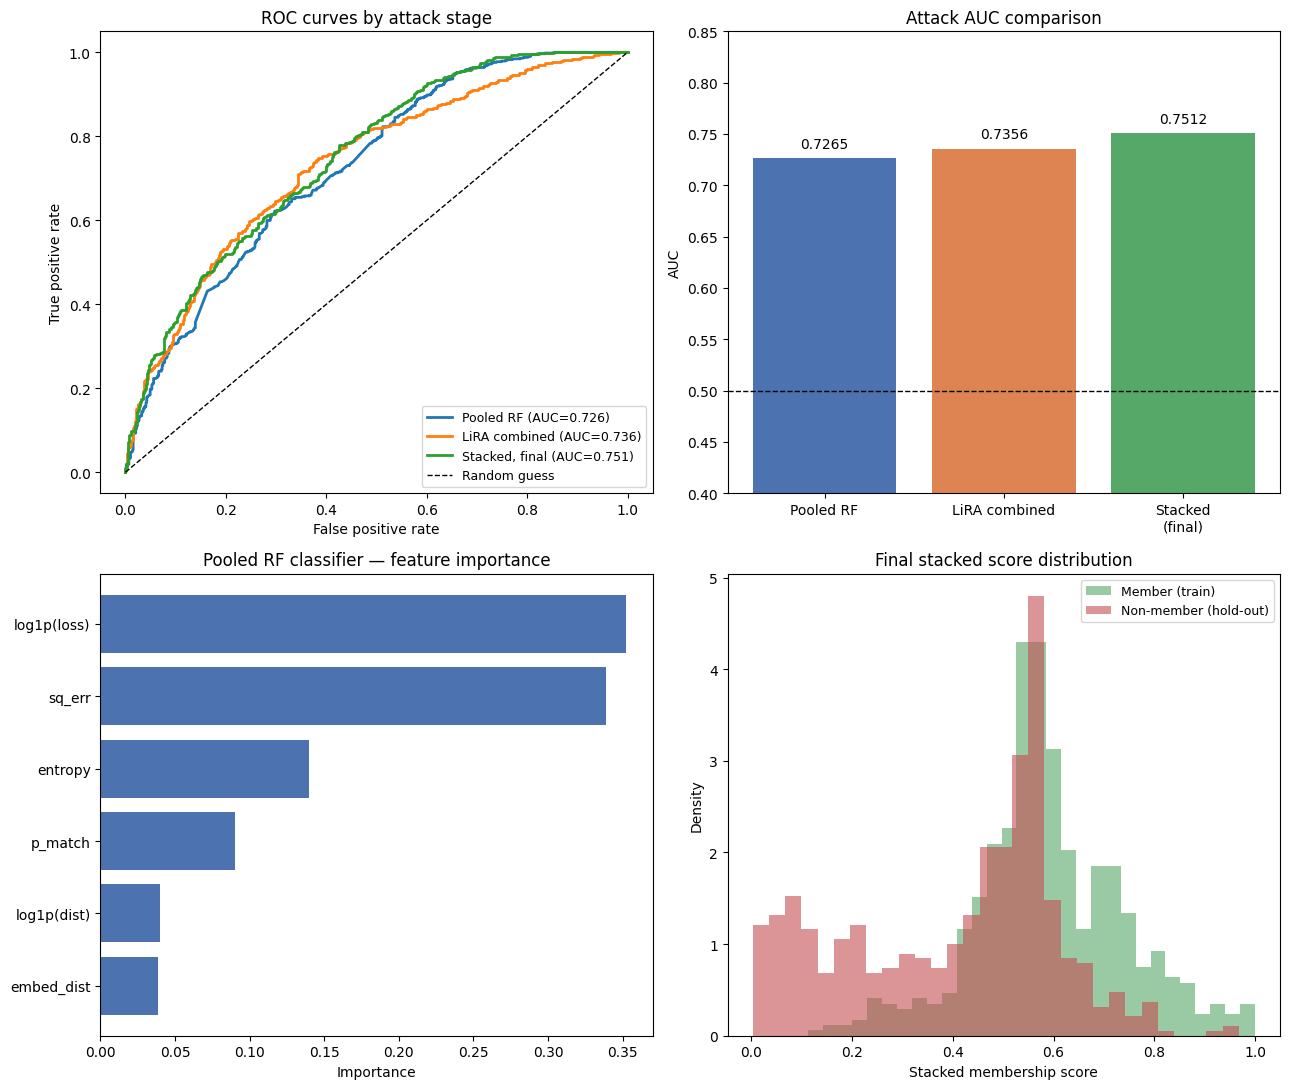

Saved figure to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/Prototypes/k_runs/final_stacked_20260928_173426/attack_diagnostics.png


In [12]:
# ==============================================================================
# 8. VISUAL DIAGNOSTICS
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# --- (a) ROC curves for each attack stage ---------------------------------
ax = axes[0, 0]
for name, score in [
    ("Pooled RF (AUC={:.3f})".format(roc_auc_score(y_stack, stack_X[:, 0])), stack_X[:, 0]),
    ("LiRA combined (AUC={:.3f})".format(roc_auc_score(y_stack, lira_combined[valid_mask])), lira_combined[valid_mask]),
    ("Stacked, final (AUC={:.3f})".format(stacked_auc), oof_pred),
]:
    fpr, tpr, _ = roc_curve(y_stack, score)
    ax.plot(fpr, tpr, linewidth=2, label=name)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves by attack stage")
ax.legend(fontsize=9, loc="lower right")

# --- (b) AUC comparison bar chart ------------------------------------------
ax = axes[0, 1]
auc_labels = ["Pooled RF", "LiRA combined", "Stacked\n(final)"]
auc_values = [roc_auc_score(y_stack, stack_X[:, 0]), roc_auc_score(y_stack, lira_combined[valid_mask]), stacked_auc]
bars = ax.bar(auc_labels, auc_values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
ax.set_ylim(0.4, 0.85)
ax.set_ylabel("AUC")
ax.set_title("Attack AUC comparison")
for b, v in zip(bars, auc_values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.4f}", ha="center", fontsize=10)

# --- (c) Pooled RF feature importances -------------------------------------
ax = axes[1, 0]
feat_names = ["p_match", "entropy", "log1p(loss)", "sq_err", "embed_dist", "log1p(dist)"]
importances = rf_attack.feature_importances_
order = np.argsort(importances)
ax.barh(np.array(feat_names)[order], importances[order], color="#4C72B0")
ax.set_xlabel("Importance")
ax.set_title("Pooled RF classifier — feature importance")

# --- (d) Stacked score distribution by true membership --------------------
ax = axes[1, 1]
ax.hist(oof_pred[y_stack == 1], bins=30, alpha=0.6, label="Member (train)", color="#55A868", density=True)
ax.hist(oof_pred[y_stack == 0], bins=30, alpha=0.6, label="Non-member (hold-out)", color="#C44E52", density=True)
ax.set_xlabel("Stacked membership score")
ax.set_ylabel("Density")
ax.set_title("Final stacked score distribution")
ax.legend(fontsize=9)

plt.tight_layout()
fig_path = RUN_ROOT / "attack_diagnostics.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure to:", fig_path.resolve())